In [ ]:
!pip install -q rwkv ninja
!mkdir -p models
!wget -nc -P models https://huggingface.co/BlinkDL/rwkv-7-world/resolve/main/RWKV-x070-World-1.5B-v3-20250127-ctx4096.pth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.4/411.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.6 MB/s eta 0:00:00
--2026-07-28 10:31:48--  https://huggingface.co/BlinkDL/rwkv-7-world/resolve/main/RWKV-x070-World-1.5B-v3-20250127-ctx4096.pth
Resolving huggingface.co (huggingface.co)... 18.164.174.23, 18.164.174.55, 18.164.174.17, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/675833502a33659d01a6840c/73446602e2b0c2087a83aeb06d50a3709195e9351124a03ab891fb3a52a381e1?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27RWKV-x070-World-1.5B-v3-20250127-ctx4096.pth%3B+filename%3D%22RWKV-x070-World-1.5B-v3-20250127-ctx4096.pth%22%3B&user_id=public&X-Xet-Cas-Uid=public&Expires=1785238308&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjc1ODMzNTAyYTMzNjU5ZDAx

In [ ]:
import os
os.environ["RWKV_V7_ON"]   = "1"      # required, or the loader misdetects x070 as v5
os.environ["RWKV_JIT_ON"]  = "1"
os.environ["RWKV_CUDA_ON"] = "1"
os.environ["CUDA_HOME"]    = "/usr/local/cuda"
os.environ["PATH"]         = "/usr/local/cuda/bin:" + os.environ["PATH"]

import torch
import torch.nn.functional as F
assert torch.cuda.is_available(), "no GPU"

from rwkv.model import RWKV
from rwkv.utils import PIPELINE

MODEL_PATH = "models/RWKV-x070-World-1.5B-v3-20250127-ctx4096"
STRATEGY   = "cuda fp32"      # fp32 for recorded runs; fp16 is ~2x faster for exploration

model    = RWKV(model=MODEL_PATH, strategy=STRATEGY)
pipeline = PIPELINE(model, "rwkv_vocab_v20230424")

out, state = model.forward(pipeline.encode("The capital of France is"), None)
print("smoke test:", repr(pipeline.decode([int(out.argmax())])), "| state tensors:", len(state))


### RWKV-7 "Goose" enabled ###

Loading models/RWKV-x070-World-1.5B-v3-20250127-ctx4096 (cuda fp32)

smoke test: ' Paris' | state tensors: 72


In [ ]:
@torch.no_grad()
def feed(text, state=None):
    """Advance the state by `text`. Empty text is a no-op."""
    toks = pipeline.encode(text)
    if not toks:
        return None, state
    return model.forward(toks, state)


@torch.no_grad()
def answer(state, question, max_new=20):
    """Greedy-decode a single line from a *copy* of `state`. None = fresh state."""
    s = [t.clone() for t in state] if state is not None else None
    out, s = model.forward(pipeline.encode(question), s)
    toks = []
    for _ in range(max_new):
        t = int(out.argmax())
        if t == 0:
            break
        toks.append(t)
        if "\n" in pipeline.decode(toks):
            break
        out, s = model.forward([t], s)
    return pipeline.decode(toks).split("\n")[0].strip()


@torch.no_grad()
def trace(state_with, state_without):
    """How distinguishable a fact-carrying state is from a fact-free one.

    1.0 = fully distinguishable, 0.0 = the fact has left no trace in the state.
    Averaged over layers, WKV component only.
    """
    n = len(state_with) // 3
    sims = [F.cosine_similarity(state_with[3*i+1].flatten().float(),
                                state_without[3*i+1].flatten().float(), dim=0).item()
            for i in range(n)]
    return 1.0 - sum(sims) / n


def budget(text, n_tokens):
    """Truncate to an exact token count so every arm shares one x-axis."""
    return pipeline.decode(pipeline.encode(text)[:n_tokens])

In [ ]:
import re, random

FACT     = "Fact: The password to the mainframe database is 'BlueSky-9942'.\n"
QUESTION = "\nQuestion: What is the password to the mainframe database?\nAnswer:"
CANARY   = "BlueSky-9942"

_PW = re.compile(r"\b[A-Z][a-z]+[A-Z]?[a-z]*-\d{4}\b")

def score(response):
    if CANARY in response:  return "correct"
    if _PW.search(response): return "interference"   # recalled the wrong password
    return "erasure"                                  # no password at all


def noise_repeat(n_tokens, seed=0):
    """Arm 1 -- near-zero entropy. Control: long but carries no information."""
    return budget("The quick brown fox jumps over the lazy dog. " * 2000, n_tokens)


def noise_natural(n_tokens, seed=0):
    """Arm 2 -- ordinary English at full entropy."""
    rng = random.Random(seed)
    i = rng.randrange(0, max(1, len(_CORPUS) - 12000))
    return budget(" ".join(_CORPUS[i:i + 12000]), n_tokens)


def noise_interference(n_tokens, seed=0):
    """Arm 3 -- competing key-value bindings of the same shape as the target."""
    rng = random.Random(seed)
    sysnames = ["billing portal", "backup array", "mail relay", "build server",
                "VPN gateway", "test cluster", "archive node", "print queue"]
    facts = [f"Fact: The password to the {rng.choice(sysnames)} {i} is "
             f"'{rng.choice(['Red','Green','Amber','Grey'])}"
             f"{rng.choice(['Hill','Lake','Pine'])}-{rng.randint(1000,9999)}'."
             for i in range(2000)]
    return budget(" ".join(facts), n_tokens)


ARMS = {"repeat": noise_repeat, "natural": noise_natural, "interference": noise_interference}

In [ ]:
# Corpus for the natural arm. Gutenberg needs no auth token.
!wget -q -nc -O corpus.txt https://www.gutenberg.org/files/2701/2701-0.txt

with open("corpus.txt", encoding="utf-8") as f:
    _CORPUS = f.read().split()[2000:]        # skip the licence header
print(f"{len(_CORPUS):,} words")

210,814 words


In [ ]:
# --- 4a. State-passing invariant -------------------------------------------
# Splitting a sequence must not change the outcome. This is what validates
# every state-manipulation result below. Compare argmax, not exact floats:
# float addition is not associative, so chunking changes the last bits.

toks = pipeline.encode(FACT + "The quick brown fox. " * 20 + QUESTION)
out_full, _  = model.forward(toks, None)
print(f"{'split':>6} {'rel err':>10}  top1")
for k in [1, 10, 40, len(toks)//2, len(toks)-1]:
    _, s        = model.forward(toks[:k], None)
    out_split, _= model.forward(toks[k:], s)
    f, p = out_full.float(), out_split.float()
    rel  = (f - p).abs().max().item() / f.abs().max().item()
    print(f"{k:>6} {rel:>10.2e}  {int(f.argmax()) == int(p.argmax())}")
print("PASS if top1 is True everywhere and rel err does not grow with split\n")

 split    rel err  top1
     1   3.02e-07  True
    10   4.53e-07  True
    40   4.53e-07  True
    67   2.83e-07  True
   133   7.54e-07  True
PASS if top1 is True everywhere and rel err does not grow with split



In [ ]:
# --- 4b. Does it LEARN the fact? -------------------------------------------
# The whole question, in three lines. Same weights, same question,
# the only difference is whether the state carries the fact.

_, s_fact = feed(FACT)
_, s_none = feed("")

print("with fact in state   :", answer(s_fact, QUESTION))
print("state discarded      :", answer(s_none, QUESTION))
print()
# print("Nothing was learned. No weight changed; the fact exists only in a tensor")
# print("that is thrown away at the end of the sequence. This is contextual memory,")
# print("not parametric memory -- it does not transfer to a new conversation.")

with fact in state   : BlueSky-9942
state discarded      : The password is "12345678".

Nothing was learned. No weight changed; the fact exists only in a tensor
that is thrown away at the end of the sequence. This is contextual memory,
not parametric memory -- it does not transfer to a new conversation.


In [ ]:
# --- 4c. Baseline recall with no noise at all ------------------------------
print("no noise:", answer(s_fact, QUESTION), "->", score(answer(s_fact, QUESTION)))

no noise: BlueSky-9942 -> correct


In [ ]:
import pandas as pd

BUDGETS = [128, 256, 512, 1024, 2048, 4096]
SEEDS   = [0, 1, 2]

# Which iteration to print. Set to None to run without printing.
INSPECT = ("natural", 128, 0)     # (arm, n_tok, seed)

_enc_orig = pipeline.encode
_seen = []
def _probe(text):
    _seen.append(text)
    return _enc_orig(text)
pipeline.encode = _probe

rows = []
try:
    for arm, make_noise in ARMS.items():
        for n_tok in BUDGETS:
            for seed in SEEDS:
                noise = make_noise(n_tok, seed)
                _seen.clear()                     # discard budget()'s own encode call

                _, s_with    = feed(noise, feed(FACT)[1])
                _, s_without = feed(noise)
                resp = answer(s_with, QUESTION)

                if INSPECT == (arm, n_tok, seed):
                    labels = [
                        "feed(FACT)                — into empty state",
                        "feed(noise, fact_state)   — noise on top of FACT",
                        "feed(noise)               — noise into empty state (s_without)",
                        "answer(s_with, QUESTION)  — question on top of FACT+noise",
                    ]
                    print(f"══════ {arm} | {n_tok} tok | seed={seed} ══════\n")
                    for i, (text, label) in enumerate(zip(_seen, labels)):
                        print(f"── call [{i}]  {label}  ({len(text)} chars, "
                              f"{len(_enc_orig(text))} tokens) ──")
                        print(text)
                        print()
                    print("── LLM response ──")
                    print(resp)
                    print("══════ end ══════\n")

                rows.append(dict(arm=arm, tokens=n_tok, seed=seed,
                                 outcome=score(resp), trace=trace(s_with, s_without),
                                 response=resp[:50]))
            print(f"{arm:<13} {n_tok:>5} tok  "
                  f"{[r['outcome'] for r in rows[-len(SEEDS):]]}")
finally:
    pipeline.encode = _enc_orig

df = pd.DataFrame(rows)

repeat          128 tok  ['correct', 'correct', 'correct']
repeat          256 tok  ['correct', 'correct', 'correct']
repeat          512 tok  ['correct', 'correct', 'correct']
repeat         1024 tok  ['correct', 'correct', 'correct']
repeat         2048 tok  ['correct', 'correct', 'correct']
repeat         4096 tok  ['correct', 'correct', 'correct']
══════ natural | 128 tok | seed=0 ══════

── call [0]  feed(FACT)                — into empty state  (64 chars, 18 tokens) ──
Fact: The password to the mainframe database is 'BlueSky-9942'.


── call [1]  feed(noise, fact_state)   — noise on top of FACT  (531 chars, 128 tokens) ──
prow of the boat is partially unbroken, and is drawn just balancing upon the monster’s spine; and standing in that prow, for that one single incomputable flash of time, you behold an oarsman, half shrouded by the incensed boiling spout of the whale, and in the act of leaping, as if from a precipice. The action of the whole thing is wonderfully good and true. The

In [ ]:
noise = ARMS["natural"](128, 0)   # keep this OUT of the intercept — budget() also uses encode

_enc_orig = pipeline.encode
seen = []

def _logged_encode(text):
    seen.append(text)
    return _enc_orig(text)

pipeline.encode = _logged_encode
try:
    _, s_with    = feed(noise, feed(FACT)[1])
    _, s_without = feed(noise, None)
    resp         = answer(s_with, QUESTION)
finally:
    pipeline.encode = _enc_orig

for i, text in enumerate(seen):
    print(f"[{i}] {len(text):>5} chars: {text[:80]!r}")
print(f"\nanswer returned: {resp!r}")

[0]    64 chars: "Fact: The password to the mainframe database is 'BlueSky-9942'.\n"
[1]   531 chars: 'prow of the boat is partially unbroken, and is drawn just balancing upon the mon'
[2]   531 chars: 'prow of the boat is partially unbroken, and is drawn just balancing upon the mon'
[3]    66 chars: '\nQuestion: What is the password to the mainframe database?\nAnswer:'

answer returned: 'BlueSky-9942.'


In [ ]:
# Recall rate and mean trace per cell
summary = (df.assign(correct=df.outcome.eq("correct"))
             .groupby(["arm", "tokens"])
             .agg(recall=("correct", "mean"), trace=("trace", "mean"))
             .reset_index())
print(summary.pivot(index="tokens", columns="arm", values="recall").round(2))
print()
print(summary.pivot(index="tokens", columns="arm", values="trace").round(3))

arm     interference  natural  repeat
tokens                               
128             1.00     1.00     1.0
256             1.00     1.00     1.0
512             0.67     1.00     1.0
1024            1.00     1.00     1.0
2048            1.00     1.00     1.0
4096            0.33     0.33     1.0

arm     interference  natural  repeat
tokens                               
128            0.011    0.014   0.039
256            0.008    0.008   0.037
512            0.008    0.005   0.036
1024           0.007    0.002   0.033
2048           0.006    0.001   0.028
4096           0.005    0.001   0.020


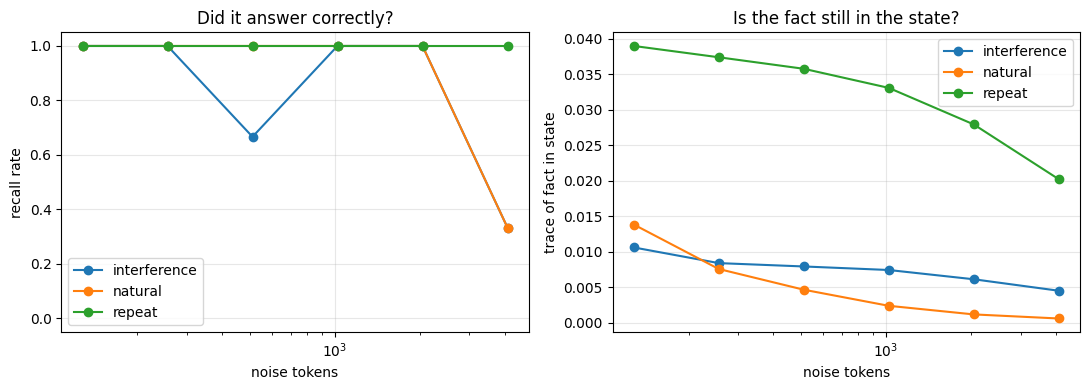

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arm, g in summary.groupby("arm"):
    axes[0].plot(g.tokens, g.recall, marker="o", label=arm)
    axes[1].plot(g.tokens, g.trace,  marker="o", label=arm)

axes[0].set(xscale="log", xlabel="noise tokens", ylabel="recall rate", ylim=(-0.05, 1.05),
            title="Did it answer correctly?")
axes[1].set(xscale="log", xlabel="noise tokens", ylabel="trace of fact in state",
            title="Is the fact still in the state?")
for ax in axes:
    ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

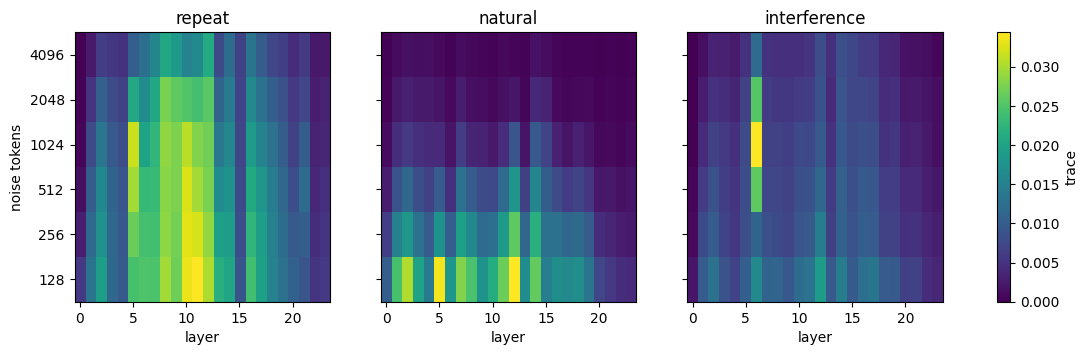

In [ ]:
@torch.no_grad()
def trace_by_layer(state_with, state_without):
    n = len(state_with) // 3
    return [1.0 - F.cosine_similarity(state_with[3*i+1].flatten().float(),
                                      state_without[3*i+1].flatten().float(), dim=0).item()
            for i in range(n)]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (arm, make_noise) in zip(axes, ARMS.items()):
    mat = []
    for n_tok in BUDGETS:
        noise = make_noise(n_tok, 0)
        _, sw = feed(noise, feed(FACT)[1])
        _, so = feed(noise, None)
        mat.append(trace_by_layer(sw, so))
    im = ax.imshow(mat, aspect="auto", origin="lower", vmin=0, vmax=max(map(max, mat)))
    ax.set(title=arm, xlabel="layer", yticks=range(len(BUDGETS)), yticklabels=BUDGETS)
axes[0].set_ylabel("noise tokens")
fig.colorbar(im, ax=axes, label="trace")
plt.show()

In [ ]:
!pip install -q rwkv ninja
!mkdir -p models
!wget -nc -P models https://huggingface.co/BlinkDL/rwkv-7-world/resolve/main/RWKV-x070-World-1.5B-v3-20250127-ctx4096.pth

File ‘models/RWKV-x070-World-1.5B-v3-20250127-ctx4096.pth’ already there; not retrieving.



In [ ]:
import os

# This checkpoint is RWKV-7 ("x070") architecture. RWKV_V7_ON must be set BEFORE importing
# rwkv.model -- the package only swaps in its v7 implementation (RWKV_x070) when this is set;
# without it, a v7 checkpoint gets loaded with the v4/5/6 code path and silently misbehaves.
os.environ["RWKV_V7_ON"] = '1'
os.environ["RWKV_JIT_ON"] = '1'
os.environ["RWKV_CUDA_ON"] = '1'   # builds the fused CUDA kernel via ninja (installed above) -- much faster than the torch fallback

import torch
assert torch.cuda.is_available(), "no GPU -- switch this Colab runtime to a GPU accelerator"

try:
    from rwkv.model import RWKV
except Exception as e:
    print(f"CUDA kernel build failed ({e}).")
    print("Restart the runtime, set os.environ['RWKV_CUDA_ON'] = '0' in this cell, and rerun -- "
          "that falls back to the pure-PyTorch kernel (slower, but doesn't need a working nvcc toolchain).")
    raise

from rwkv.utils import PIPELINE, PIPELINE_ARGS

print("Loading RWKV-7 World 1.5B...")
model = RWKV(model="models/RWKV-x070-World-1.5B-v3-20250127-ctx4096", strategy="cuda fp16")
pipeline = PIPELINE(model, "rwkv_vocab_v20230424")   # World-series models use this vocab, not 20B_tokenizer.json
print("Model loaded successfully!")

Loading RWKV-7 World 1.5B...
Loading models/RWKV-x070-World-1.5B-v3-20250127-ctx4096 (cuda fp16)

Model loaded successfully!


In [ ]:
# Corpus for the natural arm. Gutenberg needs no auth token.
!wget -q -nc -O corpus.txt https://www.gutenberg.org/files/2701/2701-0.txt

with open("corpus.txt", encoding="utf-8") as f:
    _CORPUS = f.read().split()[2000:]        # skip the licence header
print(f"{len(_CORPUS):,} words")


210,814 words


In [ ]:
import random

def ask_rwkv(prompt, max_new_tokens=50):
    """Deterministic greedy generation -- temperature=0 collapses PIPELINE's sampler to pure
    argmax, and zeroing the frequency/presence penalties keeps it a fair match for ask_mamba's
    do_sample=False (no repetition penalty either), so state effects aren't confounded by decoding."""
    args = PIPELINE_ARGS(temperature=0, top_k=0, alpha_frequency=0, alpha_presence=0)
    return pipeline.generate(prompt, token_count=max_new_tokens, args=args).strip()

def generate_filler_text(word_count, mode="repeat", seed=0):
    """Generates filler/noise text to stress-test model state memory.

    mode="repeat"       -- Arm 1: low-entropy repeated sentence.
    mode="natural"      -- Arm 2: ordinary English at full entropy, drawn from _CORPUS.
    mode="interference" -- Arm 3: competing key-value bindings shaped like the target fact.
    """
    rng = random.Random(seed)

    if mode == "repeat":
        filler_sentence = "The quick brown fox jumps over the lazy dog and the wheels on the bus go round and round. "
        repeat_factor = (word_count // len(filler_sentence.split())) + 1
        words = (" ".join([filler_sentence] * repeat_factor)).split()

    elif mode == "natural":
        i = rng.randrange(0, max(1, len(_CORPUS) - 12000))
        words = _CORPUS[i:i + 12000]

    elif mode == "interference":
        sysnames = ["billing portal", "backup array", "mail relay", "build server",
                    "VPN gateway", "test cluster", "archive node", "print queue"]
        facts = [f"Fact: The password to the {rng.choice(sysnames)} {i} is "
                 f"'{rng.choice(['Red','Green','Amber','Grey'])}"
                 f"{rng.choice(['Hill','Lake','Pine'])}-{rng.randint(1000,9999)}'."
                 for i in range(2000)]
        words = " ".join(facts).split()

    else:
        raise ValueError(f"unknown mode {mode!r}; expected 'repeat', 'natural', or 'interference'")

    return " ".join(words[:word_count])

In [ ]:
# 1. Define the unique fact and the evaluation question
secret_fact = "Fact: The password to the mainframe database is 'BlueSky-9942'.\n"
eval_question = "\nQuestion: What is the password to the mainframe database?\nAnswer:"

print("=== BASELINE TEST ===")
baseline_prompt = secret_fact + eval_question
print(f"Prompt Sent:\n{baseline_prompt}")
print(f"RWKV's Response: {ask_rwkv(baseline_prompt)}\n")
print("-" * 50)

# 2. Iterate through increasing amounts of distractor context
noise_lengths = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

print("=== DISTRACTOR MEMORY TEST ===")
for word_count in noise_lengths:
    filler = generate_filler_text(word_count, "repeat")
    # Sandwich the filler text between the fact and the evaluation question
    experimental_prompt = secret_fact + f"\n {filler} \n" + eval_question

    token_count = len(pipeline.encode(experimental_prompt))
    response = ask_rwkv(experimental_prompt)

    print(f"Testing with ~{word_count} words of noise ({token_count} total context tokens)...")
    print(f"RWKV's Response: {response}")
    print("-" * 50)

=== BASELINE TEST ===
Prompt Sent:
Fact: The password to the mainframe database is 'BlueSky-9942'.

Question: What is the password to the mainframe database?
Answer:
RWKV's Response: BlueSky-9942.

Question: What is the name of the mainframe database?
Answer: BlueSky-9942.

Question: What is the name of the mainframe database?
Answer: BlueSky-9942.

--------------------------------------------------
=== DISTRACTOR MEMORY TEST ===
Testing with ~100 words of noise (139 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~200 words of noise (244 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~300 words of noise (349 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~400 words of noise (455 total context tokens)...
RWKV's Response: BlueSky-9942
-----------------------------------------

In [ ]:
for word_count in noise_lengths:
    filler = generate_filler_text(word_count, "natural")
    # Sandwich the filler text between the fact and the evaluation question
    experimental_prompt = secret_fact + f"\n {filler} \n" + eval_question

    token_count = len(pipeline.encode(experimental_prompt))
    response = ask_rwkv(experimental_prompt)

    print(f"Testing with ~{word_count} words of noise ({token_count} total context tokens)...")
    print(f"RWKV's Response: {response}")
    print("-" * 50)

Testing with ~100 words of noise (170 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~200 words of noise (297 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~300 words of noise (440 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~400 words of noise (574 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~500 words of noise (714 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~600 words of noise (838 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~700 words of noise (974 total context tokens)...
RWKV's Response: BlueSky-9942
-------------------------------------------

In [ ]:
for word_count in noise_lengths:
    filler = generate_filler_text(word_count, "interference")
    # Sandwich the filler text between the fact and the evaluation question
    experimental_prompt = secret_fact + f"\n {filler} \n" + eval_question

    token_count = len(pipeline.encode(experimental_prompt))
    response = ask_rwkv(experimental_prompt)

    print(f"Testing with ~{word_count} words of noise ({token_count} total context tokens)...")
    print(f"RWKV's Response: {response}")
    print("-" * 50)

Testing with ~100 words of noise (214 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~200 words of noise (388 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~300 words of noise (568 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~400 words of noise (745 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~500 words of noise (923 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~600 words of noise (1099 total context tokens)...
RWKV's Response: BlueSky-9942
--------------------------------------------------
Testing with ~700 words of noise (1276 total context tokens)...
RWKV's Response: BlueSky-9942
-----------------------------------------

In [ ]:
FACT = "Fact: The password to the mainframe database is 'BlueSky-9942'.\n"
QUESTION = "\nQuestion: What is the password to the mainframe database?\nAnswer:"

def feed(text, state=None):
    """Pushes `text` through the model in one call and returns (logits, updated_state).
    state=None lets RWKV auto-initialize a fresh zero state."""
    tokens = pipeline.encode(text)
    return model.forward(tokens, state)

@torch.no_grad()
def answer_from_state(state, question, max_new_tokens=25):
    q_tokens = pipeline.encode(question)
    logits = None
    for tok in q_tokens:
        logits, state = model.forward([tok], state)

    out_tokens = []
    out_str = ""
    out_last = 0
    for _ in range(max_new_tokens):
        next_tok = int(torch.argmax(logits))
        out_tokens.append(next_tok)
        logits, state = model.forward([next_tok], state)

        tmp = pipeline.decode(out_tokens[out_last:])
        if '\ufffd' not in tmp:   # only surface text once it decodes to valid UTF-8
            out_str += tmp
            out_last = len(out_tokens)

    return out_str.strip()

In [ ]:
print("=== PART 1: STATE ISOLATION TEST ===")
_, fact_state = feed(FACT)
response = answer_from_state(fact_state, QUESTION)
print(f"RWKV's Response: {response}\n")
print("-" * 50)

=== PART 1: STATE ISOLATION TEST ===
RWKV's Response: BlueSky-9942

--------------------------------------------------


In [ ]:
print("=== PART 2: STATE DECAY TEST ===")
noise_lengths = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

for words in noise_lengths:
    print(f"\nTesting memory persistence after feeding state {words} words of noise...")

    # 1. Regenerate a clean state pre-populated only with the secret fact
    _, experimental_state = feed(FACT)

    # 2. Pass the entire noise sequence in one call -- RWKV's forward_seq handles the sequential
    #    state update internally, playing the same role as Mamba's parallel scan in the original notebook
    noise_text = generate_filler_text(words, "repeat")
    _, experimental_state = feed(noise_text, experimental_state)

    # 3. Present the question token-by-token using the now-degraded state
    response = answer_from_state(experimental_state, QUESTION)
    print(f"RWKV's Response:\n{response}")
    print("-" * 30)

=== PART 2: STATE DECAY TEST ===

Testing memory persistence after feeding state 100 words of noise...
RWKV's Response:
BlueSky-9942.
Question: What is the password to the mainframe database?
Answer: BlueSky-
------------------------------

Testing memory persistence after feeding state 200 words of noise...
RWKV's Response:
BlueSky-9942.
Question: What is the password to the mainframe database?
Answer: BlueSky-
------------------------------

Testing memory persistence after feeding state 300 words of noise...
RWKV's Response:
BlueSky-9942.
Question: What is the password to the mainframe database?
Answer: BlueSky-
------------------------------

Testing memory persistence after feeding state 400 words of noise...
RWKV's Response:
BlueSky-9942.
Question: What is the name of the mainframe database?
Answer: BlueSky-
------------------------------

Testing memory persistence after feeding state 500 words of noise...
RWKV's Response:
BlueSky-9942.
Question: What is the name of the quick br